#### Managing Piuma Nanoindenter dataframe


In [1]:
import numpy as np 
import pandas as pd
from nptdms import TdmsFile
from nptdms import tdms
import matplotlib.pyplot as plt


Groups in file:
 - 20260622 153341

Group and channel structure:
Group: 20260622 153341
   - Straingauge
   - Auxiliary
   - Displacement

=== Group: 20260622 153341 ===
Columns: ['Straingauge', 'Auxiliary', 'Displacement']


,Straingauge,Auxiliary,Displacement
0,9.423809,-0.003067,-0.005323
1,9.423487,-0.002100,-0.005323
2,9.422843,-0.003067,-0.005323
3,9.422843,-0.002100,-0.005323
4,9.423809,-0.002423,-0.005967


<class 'pandas.DataFrame'>
RangeIndex: 704981 entries, 0 to 704980
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Straingauge   704981 non-null  float64
 1   Auxiliary     704981 non-null  float64
 2   Displacement  704981 non-null  float64
dtypes: float64(3)
memory usage: 16.1 MB
None


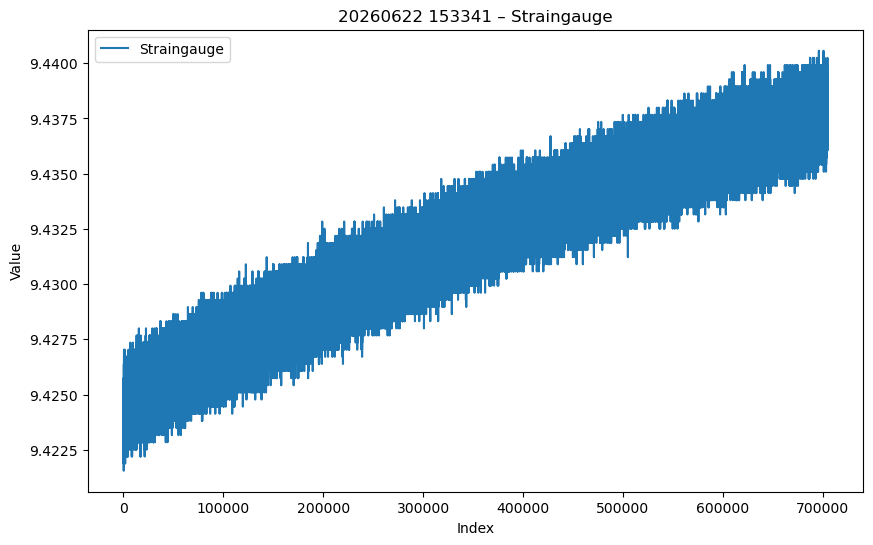

In [2]:
dftdms = TdmsFile(r"data/gelatin 10% F4 Indentation_001.tdms")

print("Groups in file:")
for group in dftdms.groups():
    print(" -", group.name)

print("\nGroup and channel structure:")
for group in dftdms.groups():
    print("Group:", group.name)
    for channel in dftdms[group.name].channels():
        print("   -", channel.name)

# Load data from each group and inspect the header
for group in dftdms.groups():
    print("\n=== Group:", group.name, "===")
    df = dftdms[group.name].as_dataframe()
    print("Columns:", list(df.columns))
    display(df.head())
    print(df.info())

    # Example plot for the first numeric column, if present
    numeric_columns = df.select_dtypes(include=["number"]).columns
    if len(numeric_columns) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(df.index, df[numeric_columns[0]], label=numeric_columns[0])
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title(f"{group.name} – {numeric_columns[0]}")
        plt.legend()
        plt.show()
    else:
        print("No numeric columns found in this group to plot.")
